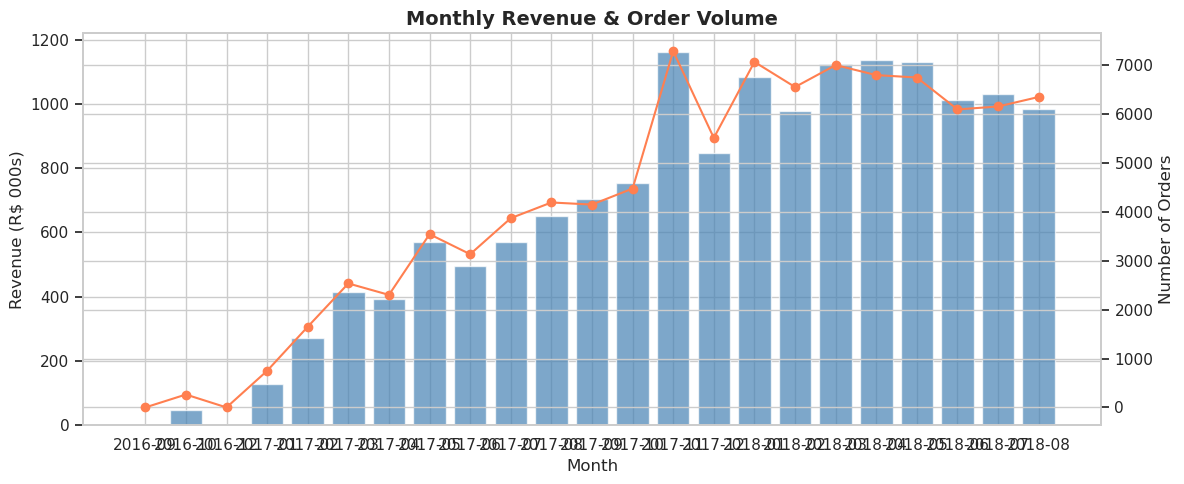

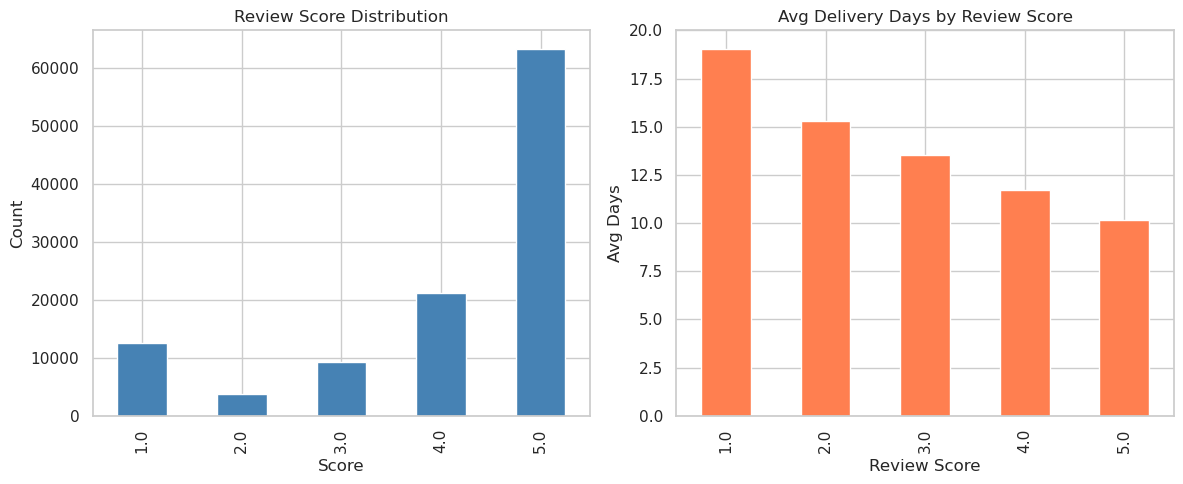

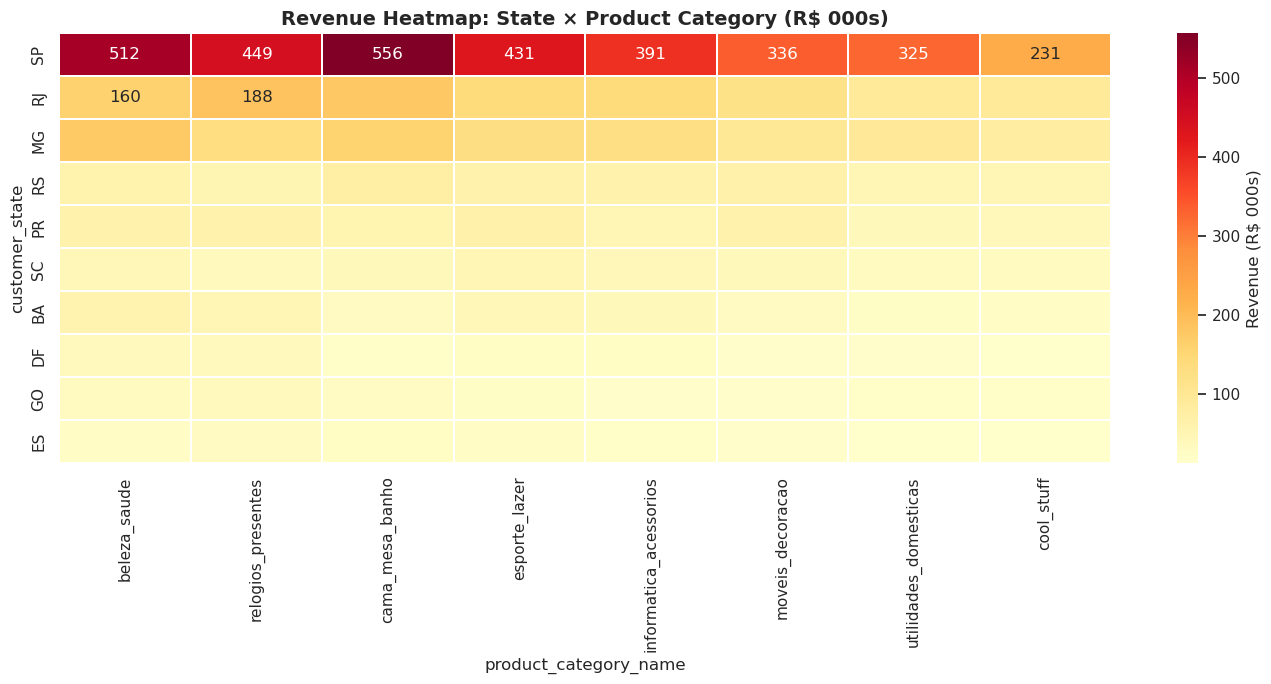

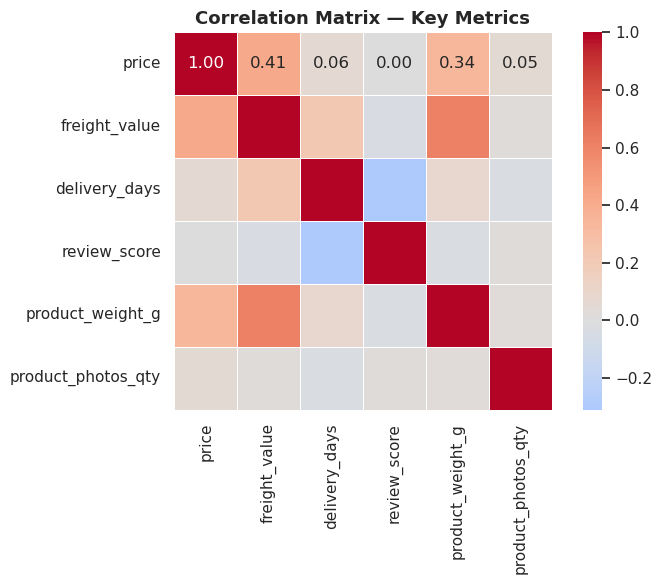

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
# --- Style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

master = pd.read_csv(r"D:\Data Analytics Projects\E-Commerce 360\data\processed\master_orders.csv", parse_dates=['order_purchase_timestamp'])

# ===== CHART 1: Monthly Revenue Trend =====
monthly = master.groupby('order_month').agg(
    revenue=('total_value', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)

fig, ax1 = plt.subplots()
ax1.bar(monthly['order_month'], monthly['revenue']/1000, color='steelblue', alpha=0.7, label='Revenue (R$ 000s)')
ax2 = ax1.twinx()
ax2.plot(monthly['order_month'], monthly['orders'], color='coral', marker='o', label='# Orders')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (R$ 000s)')
ax2.set_ylabel('Number of Orders')
ax1.set_title('Monthly Revenue & Order Volume', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig(r"D:\Data Analytics Projects\E-Commerce 360\python_charts\monthly_revenue.png", dpi=150)
plt.show()


# ===== CHART 2: Review Score Distribution =====
fig, axes = plt.subplots(1, 2)
master['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', title='Review Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Review score vs. delivery time
master.groupby('review_score')['delivery_days'].mean().plot(
    kind='bar', ax=axes[1], color='coral', title='Avg Delivery Days by Review Score')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Avg Days')
plt.tight_layout()
plt.savefig(r"D:\Data Analytics Projects\E-Commerce 360\python_charts\reviews_analysis.png", dpi=150)
plt.show()

# ===== CHART 3: Heatmap — Sales by State & Category =====
pivot = master.pivot_table(
    values='total_value', index='customer_state',
    columns='product_category_name', aggfunc='sum', fill_value=0
)
# Keep top 10 states and top 8 categories
top_states = master.groupby('customer_state')['total_value'].sum().nlargest(10).index
top_cats = master.groupby('product_category_name')['total_value'].sum().nlargest(8).index
pivot_filtered = pivot.loc[top_states, top_cats] / 1000

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_filtered, cmap='YlOrRd', annot=True, fmt='.0f',
            ax=ax, linewidths=0.3, cbar_kws={'label': 'Revenue (R$ 000s)'})
ax.set_title('Revenue Heatmap: State × Product Category (R$ 000s)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"D:\Data Analytics Projects\E-Commerce 360\python_charts\state_category_heatmap.png", dpi=150)
plt.show()

# ===== CHART 4: Correlation Analysis =====
numeric_cols = ['price', 'freight_value', 'delivery_days', 'review_score',
                'product_weight_g', 'product_photos_qty']
corr = master[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Key Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"D:\Data Analytics Projects\E-Commerce 360\python_charts\correlation_matrix.png", dpi=150)
plt.show()